### Impot libraries

In [30]:
import pandas as pd
import torch
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from torch.utils.data import Dataset
from torchvision import transforms

### Reading data

In [2]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, folder, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        folder_dir = os.path.join(data_dir, folder)
        for class_folder in os.listdir(folder_dir):
            class_path = os.path.join(folder_dir, class_folder)
                
            if os.path.isdir(class_path): 
                for filename in os.listdir(class_path):
                    if filename.endswith(".jpg") or filename.endswith(".png"): 
                        self.image_paths.append(os.path.join(class_path, filename))
                        self.labels.append(int(class_folder))

        self.labels = np.array(self.labels)


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label).long()
    

In [3]:
data_dir = "../data"

In [4]:
train_dataset = ImageDataset(data_dir, folder='train', transform=None)
val_dataset = ImageDataset(data_dir, folder='val', transform=None)
test_dataset = ImageDataset(data_dir, folder='test', transform=None)

In [5]:
unique_train_labels = np.unique(train_dataset.labels)
unique_val_labels = np.unique(val_dataset.labels)
unique_test_labels = np.unique(test_dataset.labels)

print("Unique train labels:", unique_train_labels)
print("train size:", len(train_dataset))
print("Unique validation labels:", unique_val_labels)
print("val size:", len(val_dataset))
print("Unique test labels:", unique_test_labels)
print("test size:", len(test_dataset))

Unique train labels: [0 1 2 3 4 5 6]
train size: 28709
Unique validation labels: [0 1 2 3 4 5 6]
val size: 3589
Unique test labels: [0 1 2 3 4 5 6]
test size: 3589


In [14]:
def eval_data(data_dir, folder, sample_number, transform=None):
    if transform is None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    
    dataset = ImageDataset(data_dir=data_dir, folder=folder, transform=transform)
    image, label = dataset[sample_number] 
    image_np = image.permute(1, 2, 0).numpy()
    image_np = (image_np * 0.5 + 0.5).clip(0, 1)

    print('Label: ', label.item())
    plt.imshow(image_np)
    plt.axis('off')
    plt.show()
    

Label:  3


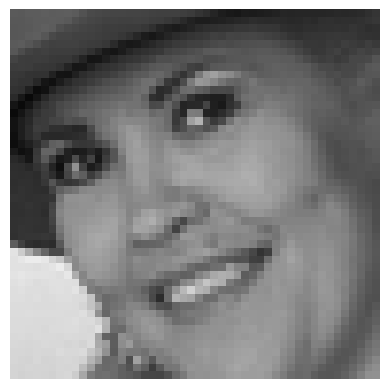

In [15]:
eval_data(data_dir, folder='train', sample_number=1)

### Distribution of classes

In [38]:
from collections import Counter

def show_distribution(dataset):

    sns.set(style="whitegrid")
    
    labels = dataset.labels
    class_counts = Counter(labels)
    
    plt.figure(figsize=(12, 7))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color=sns.color_palette("viridis", len(class_counts)), edgecolor='black')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=12)
    
    
    plt.xlabel('Class Labels', fontsize=14, fontweight='bold')
    plt.ylabel('Frequency', fontsize=14, fontweight='bold')
    plt.title(f'Class Distribution in Dataset', fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()


For Train dataset: 


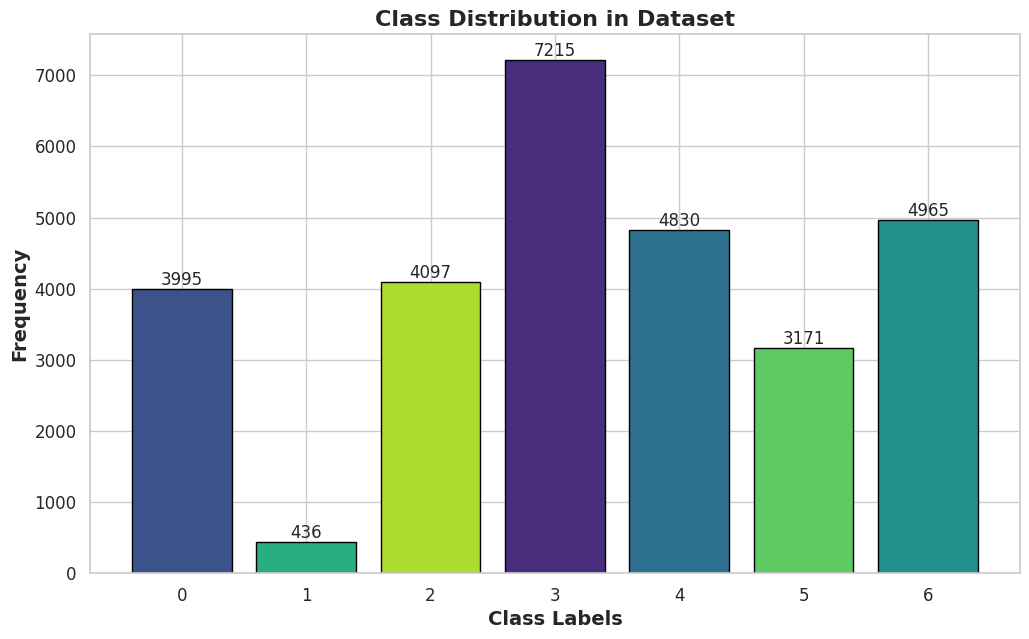

In [40]:
print("For Train dataset: ")
show_distribution(train_dataset)

### Generate data

In [31]:
def generate_data(dataset, data_dir, folder, min_class, target_count):
  
    class_counts = {label: np.sum(dataset.labels == label) for label in np.unique(dataset.labels)}

    augmentation_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomResizedCrop(size=(48, 48), scale=(0.8, 1.0)),
        transforms.ToTensor()
    ])

    for class_label, count in class_counts.items(): 
        if count < min_class:
            class_indices = [i for i, label in enumerate(dataset.labels) if label == class_label]
            aug_image_count = target_count - count
            
            for _ in range(aug_image_count):
                original_image, label = dataset[random.choice(class_indices)]
                augmented_image = augmentation_transform(original_image)
                 
                class_dir = os.path.join(data_dir, folder, str(class_label))
                os.makedirs(class_dir, exist_ok=True)
                
                aug_image_path = os.path.join(class_dir, f"aug_{random.randint(1, int(1e6))}.png")
                augmented_image_pil = transforms.ToPILImage()(augmented_image)
                augmented_image_pil.save(aug_image_path)

    return 

In [32]:
min_class = 5000
target_count = 7000
train_aug_data = generate_data(train_dataset, data_dir, 'train', min_class, target_count)

In [41]:
print("For Train dataset with augmentation: ")
show_distribution(train_aug_data)

For Train dataset with augmentation: 


AttributeError: 'NoneType' object has no attribute 'labels'